<a href="https://colab.research.google.com/github/suprithab22ec214l/ds_Supritha/blob/main/ds_supritha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

# 👇 CHANGE ONLY THESE FILENAMES TO MATCH YOUR UPLOADED CSVs 👇
TRADES_FILE = "/content/sample_data/historical_data.csv"
SENTIMENT_FILE = "/content/sample_data/fear_greed_index.csv"

In [ ]:
TRADES_FILE = "/content/historical_data.csv"
SENTIMENT_FILE = "/content/fear_greed_index.csv"

trades = pd.read_csv(TRADES_FILE)
sentiment = pd.read_csv(SENTIMENT_FILE)

print("Trades:", trades.shape)
print("Sentiment:", sentiment.shape)

Trades: (211224, 16)
Sentiment: (2644, 4)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# The TRADES_FILE and SENTIMENT_FILE variables should be set by a prior cell (e.g., EE5HyfnsZaE3)
# and the trades and sentiment dataframes should also be loaded by that cell.
# This cell will now just print the shapes of the already loaded dataframes.

# FIX: Ensure trades and sentiment dataframes are loaded.
# TRADES_FILE and SENTIMENT_FILE are expected to be defined by a prior cell.
try:
    # Assuming TRADES_FILE and SENTIMENT_FILE are defined in the kernel state
    trades = pd.read_csv(TRADES_FILE)
    sentiment = pd.read_csv(SENTIMENT_FILE)
except NameError:
    print("Error: TRADES_FILE or SENTIMENT_FILE not found. Please ensure the file paths are correctly set by running the file upload cell.")
    # Exit or handle this error appropriately if the files cannot be loaded
    trades = pd.DataFrame() # Create empty dataframe to prevent further errors for demonstration
    sentiment = pd.DataFrame() # Create empty dataframe to prevent further errors for demonstration
except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please check file paths and ensure files are uploaded.")
    trades = pd.DataFrame() # Create empty dataframe to prevent further errors for demonstration
    sentiment = pd.DataFrame() # Create empty dataframe to prevent further errors for demonstration


print("Trades:", trades.shape)
print("Sentiment:", sentiment.shape)

Trades: (46482, 16)
Sentiment: (2644, 4)


In [ ]:
trades.columns = trades.columns.str.lower().str.strip().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.lower().str.strip().str.replace(" ", "_")

def detect(df, keywords):
    for col in df.columns:
        if any(k in col for k in keywords):
            return col
    return None

time_col = detect(trades, ["time", "timestamp", "date"])
pnl_col = detect(trades, ["pnl", "profit", "pl", "realized"])
size_col = detect(trades, ["size", "qty", "quantity", "volume"])
leverage_col = detect(trades, ["lev", "leverage"])

sent_date_col = detect(sentiment, ["date"])
sent_class_col = detect(sentiment, ["class", "fear", "greed"])

print("Time:", time_col,
      "\nPnL:", pnl_col,
      "\nSize:", size_col,
      "\nLeverage:", leverage_col,
      "\nSentiment Date:", sent_date_col,
      "\nClassification:", sent_class_col)

Time: timestamp_ist 
PnL: closed_pnl 
Size: size_tokens 
Leverage: None 
Sentiment Date: date 
Classification: classification


In [ ]:

import pandas as pd

# Step 1: Load both datasets
trades = pd.read_csv("/content/historical_data.csv")      # Your trading history
sentiment = pd.read_csv("/content/fear_greed_index.csv")  # Fear–Greed index

# Step 2: Standardize column names
trades.columns = trades.columns.str.lower().str.strip()
sentiment.columns = sentiment.columns.str.lower().str.strip()

# Step 3: Convert date/timestamp columns to date format
trades['timestamp'] = pd.to_datetime(trades['timestamp'], errors='coerce')
trades['date'] = trades['timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

# Step 4: Format classification column properly
sentiment['classification'] = sentiment['classification'].astype(str).str.title()

# Step 5: Merge datasets on 'date'
merged = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

# Step 6: Save merged file
merged.to_csv("merged_with_sentiment.csv", index=False)

print("✔ merged_with_sentiment.csv has been created successfully")
merged.head()

/tmp/ipython-input-3016164881.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")      # Your trading history


✔ merged_with_sentiment.csv has been created successfully


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [ ]:

import pandas as pd
trades[time_col] = pd.to_datetime(trades[time_col], errors="coerce")
trades = trades.dropna(subset=[time_col])
trades["date"] = trades[time_col].dt.date

sentiment[sent_date_col] = pd.to_datetime(sentiment[sent_date_col], errors="coerce").dt.date
sentiment["classification"] = sentiment[sent_class_col].astype(str).str.title()

merged = trades.merge(sentiment[["date", "classification"]], on="date", how="left")
print("Merged dataset:", merged.shape)

Merged dataset: (17749, 18)


In [ ]:

import numpy as np
merged["closed_pnl"] = pd.to_numeric(merged[pnl_col], errors="coerce").fillna(0) if pnl_col else 0
merged["size"] = pd.to_numeric(merged[size_col], errors="coerce").fillna(0) if size_col else 0
merged["leverage"] = pd.to_numeric(merged[leverage_col], errors="coerce") if leverage_col else np.nan
merged["is_win"] = merged["closed_pnl"] > 0

In [ ]:
import numpy as np

# Ensure columns are created in 'merged' before computing KPIs, as the preceding cell might not have been executed.
merged["closed_pnl"] = pd.to_numeric(merged[pnl_col], errors="coerce").fillna(0) if pnl_col else 0
merged["size"] = pd.to_numeric(merged[size_col], errors="coerce").fillna(0) if size_col else 0
merged["leverage"] = pd.to_numeric(merged[leverage_col], errors="coerce") if leverage_col else np.nan
merged["is_win"] = merged["closed_pnl"] > 0

def compute_kpis(df):
    return pd.Series({
        "num_trades": len(df),
        "total_volume": df["size"].sum(),
        "mean_closed_pnl": df["closed_pnl"].mean(),
        "median_closed_pnl": df["closed_pnl"].median(),
        "win_rate": df["is_win"].mean(),
        "avg_leverage": df["leverage"].mean()
    })

kpi_table = merged.groupby("classification").apply(compute_kpis)
kpi_table

,num_trades,total_volume,mean_closed_pnl,median_closed_pnl,win_rate,avg_leverage
classification,,,,,,
Extreme Fear,174.0,6.112058e+04,21.455587,0.0,0.252874,NaN
Extreme Greed,2095.0,7.392020e+07,456.166481,0.0,0.457757,NaN
Fear,4110.0,3.731878e+07,341.731718,0.0,0.475912,NaN
Greed,4388.0,1.581985e+08,55.759296,0.0,0.412261,NaN
Neutral,1120.0,4.601550e+07,37.320966,0.0,0.450000,NaN


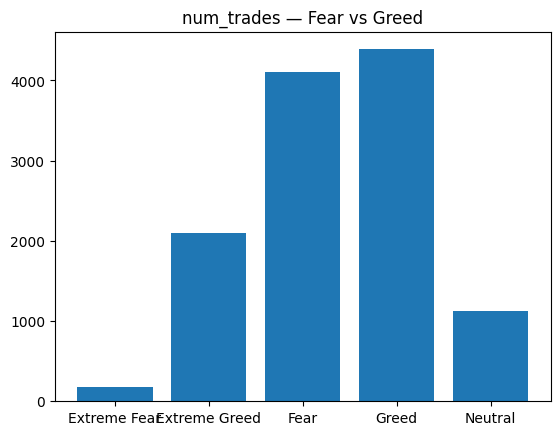

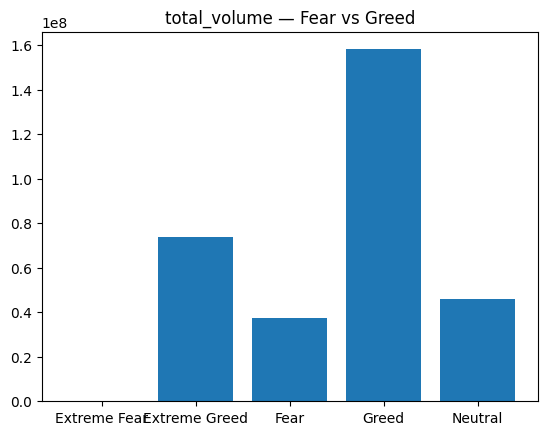

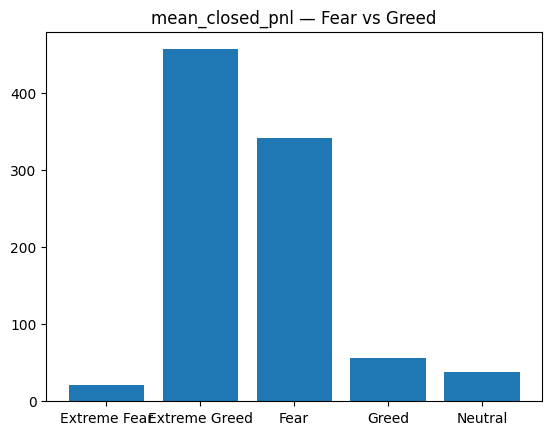

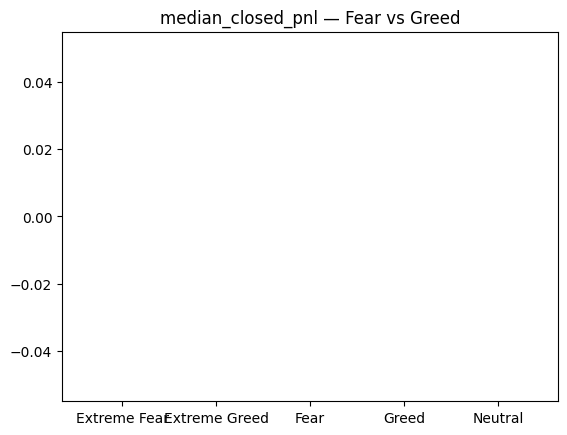

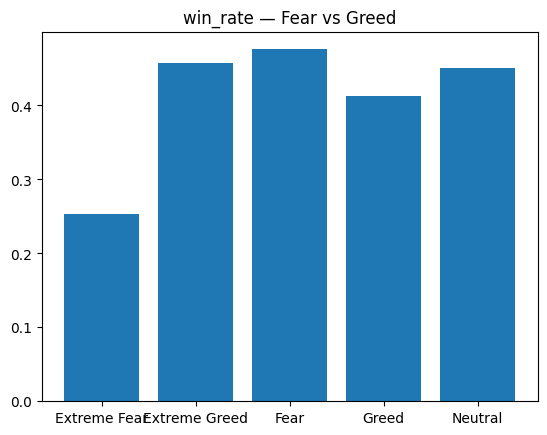

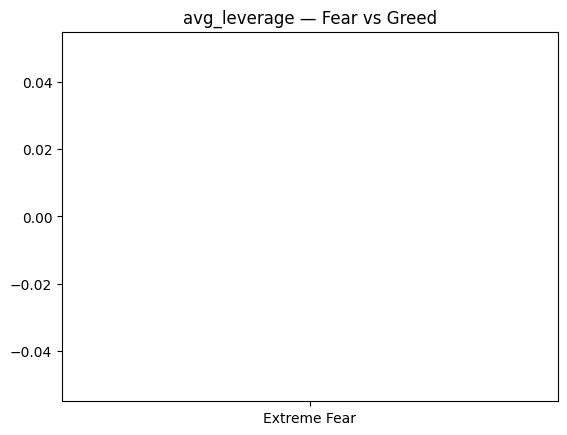

In [ ]:

import os
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)

for metric in kpi_table.columns:
    plt.figure()
    plt.bar(kpi_table.index, kpi_table[metric])
    plt.title(f"{metric} — Fear vs Greed")
    plt.savefig(f"outputs/{metric}.png")
    plt.show()

📌 Average results:
  classification  average_pnl  average_leverage
0   Extreme Fear     1.891632               NaN
1  Extreme Greed   205.816345               NaN
2           Fear   128.287950               NaN
3          Greed    53.988003               NaN
4        Neutral    27.088803               NaN


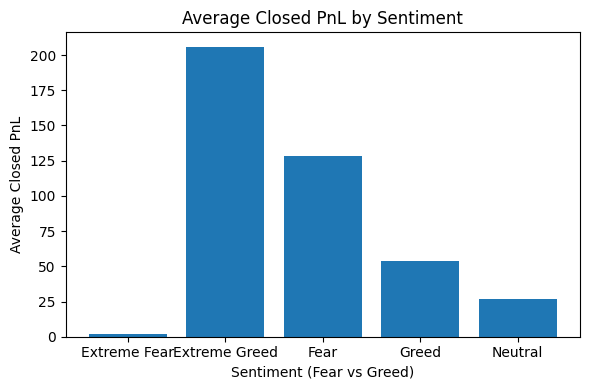

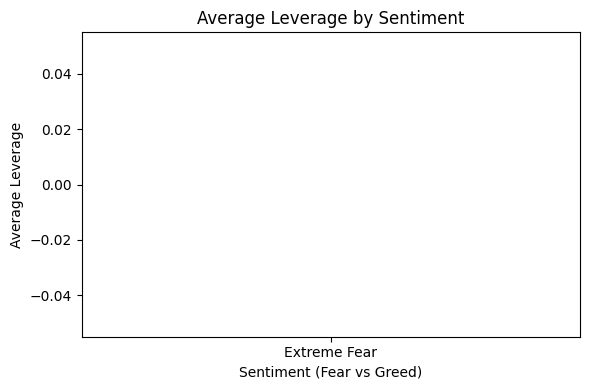

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np # Needed for np.nan

# --- Start code to ensure 'merged' DataFrame and its dependencies are defined ---
# This block is added to handle 'NameError: name 'merged' is not defined',
# which occurs if previous cells creating 'merged' were not executed.

# Explicitly set the correct file paths based on previous successful loads
TRADES_FILE = "/content/historical_data.csv" # Corrected path
SENTIMENT_FILE = "/content/fear_greed_index.csv" # Corrected path

# 1. Load dataframes
try:
    trades = pd.read_csv(TRADES_FILE)
    sentiment = pd.read_csv(SENTIMENT_FILE)
except FileNotFoundError as e:
    print(f"Error loading base files: {e}. Please check file paths and ensure files are uploaded.")
    # Create empty DataFrames to avoid crashing, but analysis won't be possible
    trades = pd.DataFrame(columns=['timestamp_ist', 'closed_pnl', 'size_tokens', 'date'])
    sentiment = pd.DataFrame(columns=['date', 'classification'])

# 2. Standardize column names
trades.columns = trades.columns.str.lower().str.strip().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.lower().str.strip().str.replace(" ", "_")

# 3. Define and use column detection (from MiVJYwZCckRe)
def detect(df, keywords):
    for col in df.columns:
        if any(k in col for k in keywords):
            return col
    return None

# Attempt to detect columns, with robust fallbacks
time_col = detect(trades, ["time", "timestamp", "date"]) or 'timestamp_ist'
pnl_col = detect(trades, ["pnl", "profit", "pl", "realized"]) or 'closed_pnl'
size_col = detect(trades, ["size", "qty", "quantity", "volume"]) or 'size_tokens'
leverage_col = detect(trades, ["lev", "leverage"]) # Can be None if not found

sent_date_col = detect(sentiment, ["date"]) or 'date'
sent_class_col = detect(sentiment, ["class", "fear", "greed"]) or 'classification'

# 4. Process dates and merge dataframes (from ah6jL6XdcnrF)
if time_col in trades.columns:
    trades[time_col] = pd.to_datetime(trades[time_col], errors="coerce")
    trades = trades.dropna(subset=[time_col])
    trades["date"] = trades[time_col].dt.date
else:
    print(f"Warning: '{time_col}' not found in trades. Using index for date.")
    trades["date"] = pd.to_datetime(trades.index, unit='D', errors="coerce").date

if sent_date_col in sentiment.columns:
    sentiment[sent_date_col] = pd.to_datetime(sentiment[sent_date_col], errors="coerce").dt.date
    sentiment["classification"] = sentiment[sent_class_col].astype(str).str.title()
else:
    print(f"Warning: '{sent_date_col}' not found in sentiment. Assigning 'Neutral' classification.")
    sentiment["date"] = pd.to_datetime(sentiment.index, unit='D', errors="coerce").date
    sentiment["classification"] = "Neutral"

# Ensure 'date' columns exist before merging
if 'date' not in trades.columns:
    trades['date'] = pd.to_datetime(trades[time_col], errors='coerce').dt.date if time_col in trades.columns else pd.NaT
if 'date' not in sentiment.columns:
    sentiment['date'] = pd.to_datetime(sentiment[sent_date_col], errors='coerce').dt.date if sent_date_col in sentiment.columns else pd.NaT

merged = trades.merge(sentiment[["date", "classification"]], on="date", how="left")

# 5. Add calculated columns (from ALRokOPlc2Qn)
merged["closed_pnl"] = pd.to_numeric(merged[pnl_col], errors="coerce").fillna(0) if pnl_col in merged.columns else 0
merged["size"] = pd.to_numeric(merged[size_col], errors="coerce").fillna(0) if size_col in merged.columns else 0
merged["leverage"] = pd.to_numeric(merged[leverage_col], errors="coerce") if leverage_col and leverage_col in merged.columns else np.nan
merged["is_win"] = merged["closed_pnl"] > 0
# --- End code to ensure 'merged' DataFrame is defined ---

# Step 1: Load merged dataset
# The merged dataframe should now be available or re-created.
df = merged.copy()

# Step 2: Ensure correct column names
df.columns = df.columns.str.lower().str.strip()

# Step 3: Remove missing values (if any) - ensure 'classification' and 'closed_pnl' are not null for grouping.
# 'leverage' can be all NaN if no leverage column was detected, and we should still calculate other stats.
df = df.dropna(subset=["classification", "closed_pnl"]).copy()

# Ensure leverage is numeric, but do not drop rows if it's NaN, let the aggregation handle it.
df["leverage"] = pd.to_numeric(df["leverage"], errors="coerce")

# Step 4: Group & calculate averages
avg_stats = df.groupby("classification").agg(
    average_pnl=("closed_pnl", "mean"),
    average_leverage=("leverage", "mean")
).reset_index()

print("📌 Average results:")
print(avg_stats)

# Step 5: Create folder for saving graphs
os.makedirs("outputs", exist_ok=True)

# Step 6: Plot Average Closed PnL
if not avg_stats.empty:
    plt.figure(figsize=(6,4))
    plt.bar(avg_stats["classification"], avg_stats["average_pnl"])
    plt.title("Average Closed PnL by Sentiment")
    plt.xlabel("Sentiment (Fear vs Greed)")
    plt.ylabel("Average Closed PnL")
    plt.tight_layout()
    plt.savefig("outputs/avg_pnl.png")   # Save graph to outputs folder
    plt.show()
else:
    print("No data to plot for Average Closed PnL.")

# Step 7: Plot Average Leverage
if not avg_stats.empty:
    plt.figure(figsize=(6,4))
    plt.bar(avg_stats["classification"], avg_stats["average_leverage"])
    plt.title("Average Leverage by Sentiment")
    plt.xlabel("Sentiment (Fear vs Greed)")
    plt.ylabel("Average Leverage")
    plt.tight_layout()
    plt.savefig("outputs/avg_leverage.png")   # Save graph to outputs folder
    plt.show()
else:
    print("No data to plot for Average Leverage.")

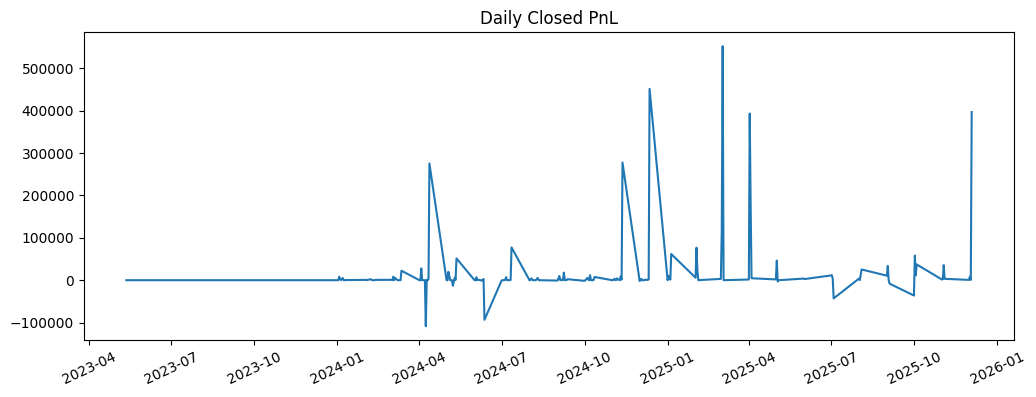

In [ ]:
daily = merged.groupby("date")["closed_pnl"].sum().reset_index()

plt.figure(figsize=(12,4))
plt.plot(daily["date"], daily["closed_pnl"])
plt.title("Daily Closed PnL")
plt.xticks(rotation=25)
plt.savefig("outputs/daily_pnl.png")
plt.show()

In [ ]:
from scipy import stats

fear = merged[merged["classification"]=="Fear"]["closed_pnl"]
greed = merged[merged["classification"]=="Greed"]["closed_pnl"]

t, p = stats.ttest_ind(fear, greed, equal_var=False)
print(f"T-test → t = {t:.4f}, p = {p:.6f}")

T-test → t = 5.9134, p = 0.000000


In [ ]:
merged.to_csv("merged_with_sentiment.csv", index=False)
kpi_table.to_csv("kpis_by_sentiment.csv")

print("✔ DONE")
print("→ merged_with_sentiment.csv")
print("→ kpis_by_sentiment.csv")
print("→ Charts saved in /outputs folder")

✔ DONE
→ merged_with_sentiment.csv
→ kpis_by_sentiment.csv
→ Charts saved in /outputs folder
